# Meta Says Performance Dropped. Did It? A Causal Approach to Finding the Truth

Imagine you're running a subscription business. You rely on Meta Ads to drive sign-ups, and you monitor daily conversions closely. One morning, you open Ads Manager and see a sharp drop in reported conversions.

Panic sets in. Did something break? Did the algorithm shift? Should you cut spend?

Before you do anything, consider what actually changed.

On March 3, 2026, Meta announced a significant update to how it measures click-through attribution. In their post [Simplifying Ad Measurement for a Social-First World](https://www.facebook.com/business/news/click-attribution), Meta explained that **click-through attribution for website and in-store conversions will now exclusively include link clicks**. Previously, Meta attributed conversions to all types of clicks: shares, saves, likes, and link clicks alike. That broader definition inflated click-through numbers relative to what third-party tools like Google Analytics would report.

Non-link-click actions (shares, saves, likes) are being moved to a newly renamed category: **engage-through attribution** (previously called engaged-view attribution).

Here is the critical part. In [that same announcement](https://www.facebook.com/business/news/click-attribution), Meta themselves acknowledge that incrementality experiments are the real standard:

> *"Incrementality experiments, like Meta's Conversion Lift, are the best way to address this question, and we believe that tests like these represent the gold standard in measurement."*

So the question is not whether Meta's numbers dropped. The question is:

> **Did performance actually change, or did the measurement change?**

## The Problem with Platform Metrics

Platform-reported metrics are:

- **Internally defined.** The platform decides what counts as a conversion.
- **Subject to change.** As we just saw, definitions can shift overnight.
- **Not equal to business outcomes.** A reported conversion is not the same as a sign-up in your database.

This is not a Meta-specific problem. Every ad platform controls its own measurement definitions. Google, TikTok, LinkedIn. They all do it. The issue is treating these numbers as ground truth when they are, by design, approximations that the platform can redefine at any time.

> **"If your measurement changes, your decisions will too, even if performance hasn't."**

That single sentence captures why platform attribution is a fragile foundation for decision-making.

## What We Should Actually Measure

The ground truth for a subscription business is **actual sign-ups**: the events recorded in your own systems, independent of any ad platform's reporting.

This distinction matters because **attribution is not incrementality**.

- **Attribution** tells you which touchpoints a platform *claims* led to a conversion.
- **Incrementality** tells you which conversions *would not have happened* without the ad.

These are fundamentally different questions. Attribution is a reporting convention. Incrementality is a causal claim.

To answer the causal question, we need experimentation.

## Our Analytical Approach

We will use an **Interrupted Time Series (ITS)** design, a quasi-experimental method that tests whether a real change occurred at a known intervention point.

The logic is straightforward:

1. Model the pre-intervention trend in the outcome variable
2. Project what would have happened if the intervention never occurred (the counterfactual)
3. Compare the actual post-intervention data to that counterfactual
4. Quantify the difference and its uncertainty

If there is no meaningful difference, the intervention had no causal effect on the outcome.

We will use **[CausalPy](https://github.com/pymc-labs/CausalPy)**, an open-source Python library for causal inference in quasi-experimental settings. It makes Bayesian causal analysis accessible without requiring heavy infrastructure, making it a good entry point for teams looking to move beyond attribution.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import causalpy as cp

print(f"CausalPy version: {cp.__version__}")

sns.set_style("whitegrid")
%config InlineBackend.figure_format = 'retina'

CausalPy version: 0.8.0


## Simulating the Scenario

We simulate 395 days of daily data: a full year of pre-intervention history (365 days) followed by 30 days after the attribution change. The start date is March 3, 2025, placing the intervention exactly on March 3, 2026, the date of Meta's announcement.

1. **Actual sign-ups (ground truth):** a slight upward trend, weekly seasonality (lower on weekends), yearly seasonality (summer peaks, winter dips), and noise. Crucially, there is **no change** after the intervention. The business is performing the same as before.

2. **Meta-reported conversions:** a fraction of actual sign-ups that Meta's attribution claims credit for, plus its own reporting noise. Pre-intervention, Meta attributes roughly **75%** of real sign-ups (counting all click types). After the intervention, the narrower link-click-only definition drops this to roughly **55%**.

We also pre-compute **Fourier features** for both yearly and weekly cycles. These give the ITS model smooth, flexible basis functions to capture seasonality. They tend to be more robust than monthly dummies when daily data does not break cleanly at calendar boundaries.

In [2]:
np.random.seed(46)
n_days = 395
intervention_day = 365
t = np.arange(n_days)

dates = pd.date_range("2025-03-03", periods=n_days, freq="D")
month = dates.month
dow = dates.dayofweek

month_effect = np.array([-5, -3, 0, 3, 5, 8, 6, 4, 2, 0, -2, -4])
monthly_seasonality = np.array([month_effect[m - 1] for m in month])

weekend_dip = np.where(dow >= 5, -6, 0).astype(float)

trend = 0.03 * t
noise_signups = np.random.normal(0, 2, n_days)
base = 100
true_signups = base + trend + monthly_seasonality + weekend_dip + noise_signups

attribution_rate_pre = 0.75
attribution_rate_post = 0.55
noise_platform = np.random.normal(0, 2, n_days)

reported = true_signups * attribution_rate_pre + noise_platform
reported[intervention_day:] = (
    true_signups[intervention_day:] * attribution_rate_post
    + noise_platform[intervention_day:]
)

df = pd.DataFrame({
    "date": dates,
    "signups": true_signups,
    "meta_reported_conversions": reported,
    "t": t,
})

for k in range(1, 4):
    df[f"sin_yearly_{k}"] = np.sin(2 * np.pi * k * t / 365.25)
    df[f"cos_yearly_{k}"] = np.cos(2 * np.pi * k * t / 365.25)

for k in range(1, 4):
    df[f"sin_weekly_{k}"] = np.sin(2 * np.pi * k * t / 7)
    df[f"cos_weekly_{k}"] = np.cos(2 * np.pi * k * t / 7)

print(f"Total days: {n_days}, Intervention at day: {intervention_day}")
print(f"Pre-intervention: {intervention_day} days, Post-intervention: {n_days - intervention_day} days")
print(f"Date range: {dates[0].date()} to {dates[-1].date()}")
print(f"Intervention date: {dates[intervention_day].date()}")
df.head()

Total days: 395, Intervention at day: 365
Pre-intervention: 365 days, Post-intervention: 30 days
Date range: 2025-03-03 to 2026-04-01
Intervention date: 2026-03-03


,date,signups,meta_reported_conversions,t,sin_yearly_1,cos_yearly_1,sin_yearly_2,cos_yearly_2,sin_yearly_3,cos_yearly_3,sin_weekly_1,cos_weekly_1,sin_weekly_2,cos_weekly_2,sin_weekly_3,cos_weekly_3
0,2025-03-03,101.169752,74.846983,0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
1,2025-03-04,102.492391,71.545798,1,0.017202,0.999852,0.034398,0.999408,0.051584,0.998669,0.781831,0.623490,0.974928,-0.222521,0.433884,-0.900969
2,2025-03-05,101.703801,76.831760,2,0.034398,0.999408,0.068755,0.997634,0.103031,0.994678,0.974928,-0.222521,-0.433884,-0.900969,-0.781831,0.623490
3,2025-03-06,98.491543,73.579561,3,0.051584,0.998669,0.103031,0.994678,0.154204,0.988039,0.433884,-0.900969,-0.781831,0.623490,0.974928,-0.222521
4,2025-03-07,100.944106,73.368754,4,0.068755,0.997634,0.137185,0.990545,0.204966,0.978769,-0.433884,-0.900969,0.781831,0.623490,-0.974928,-0.222521


## What Marketers See: The Platform View

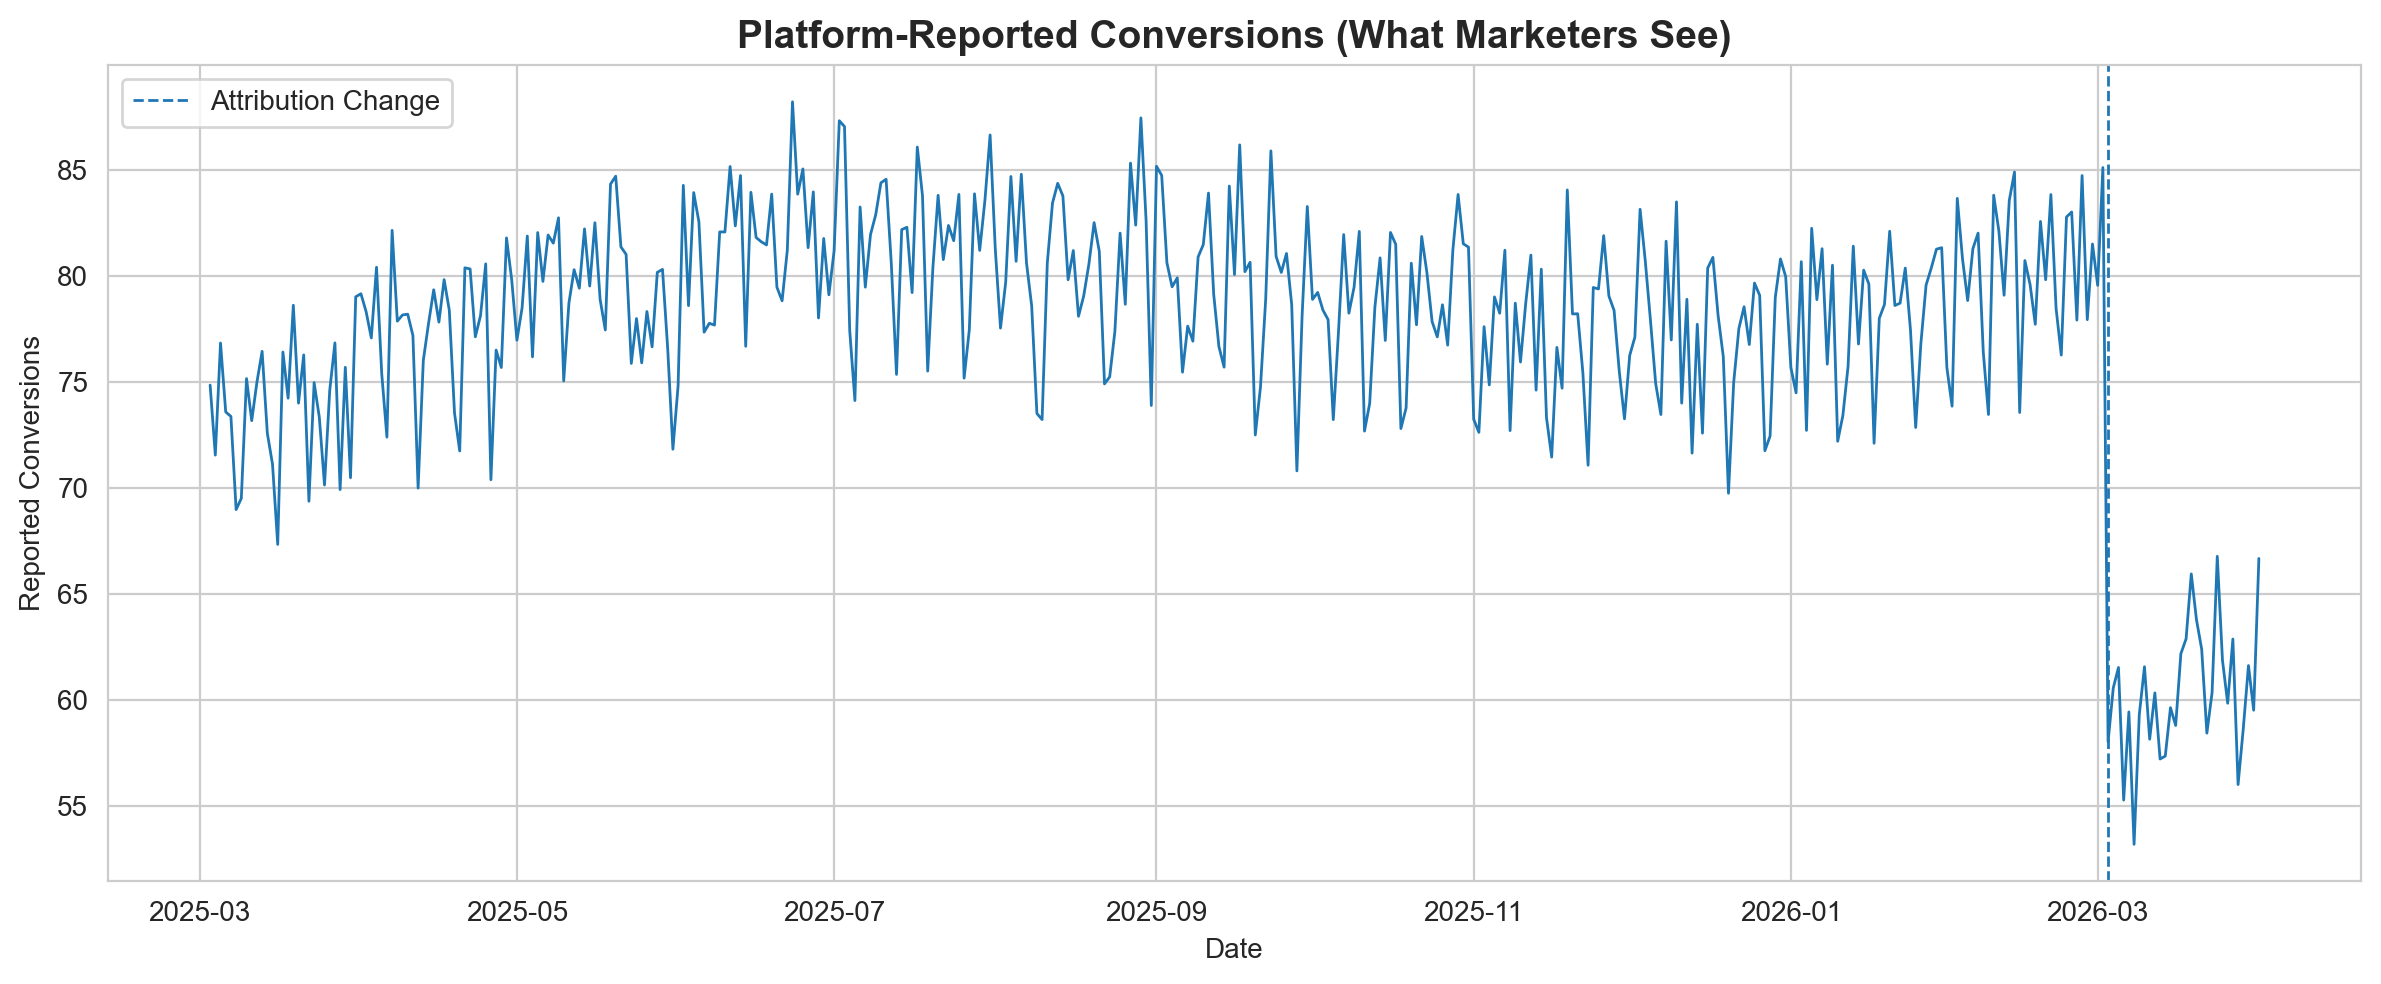

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["date"], df["meta_reported_conversions"], linewidth=1)
ax.axvline(x=dates[intervention_day], linestyle="--", linewidth=1, label="Attribution Change")
ax.set_title("Platform-Reported Conversions (What Marketers See)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Reported Conversions")
ax.legend()
plt.tight_layout()
plt.show()

This is what shows up in Ads Manager. A clear, visible drop.

If you are a marketer staring at this chart, the instinct is immediate:

- **Cut the budget** because something is clearly broken
- **Pause campaigns** to stop the bleeding
- **Swap creatives** because the current ones must have stopped working

All of these reactions are rational *given the data you are looking at*. But what if the data is wrong?

## The Ground Truth

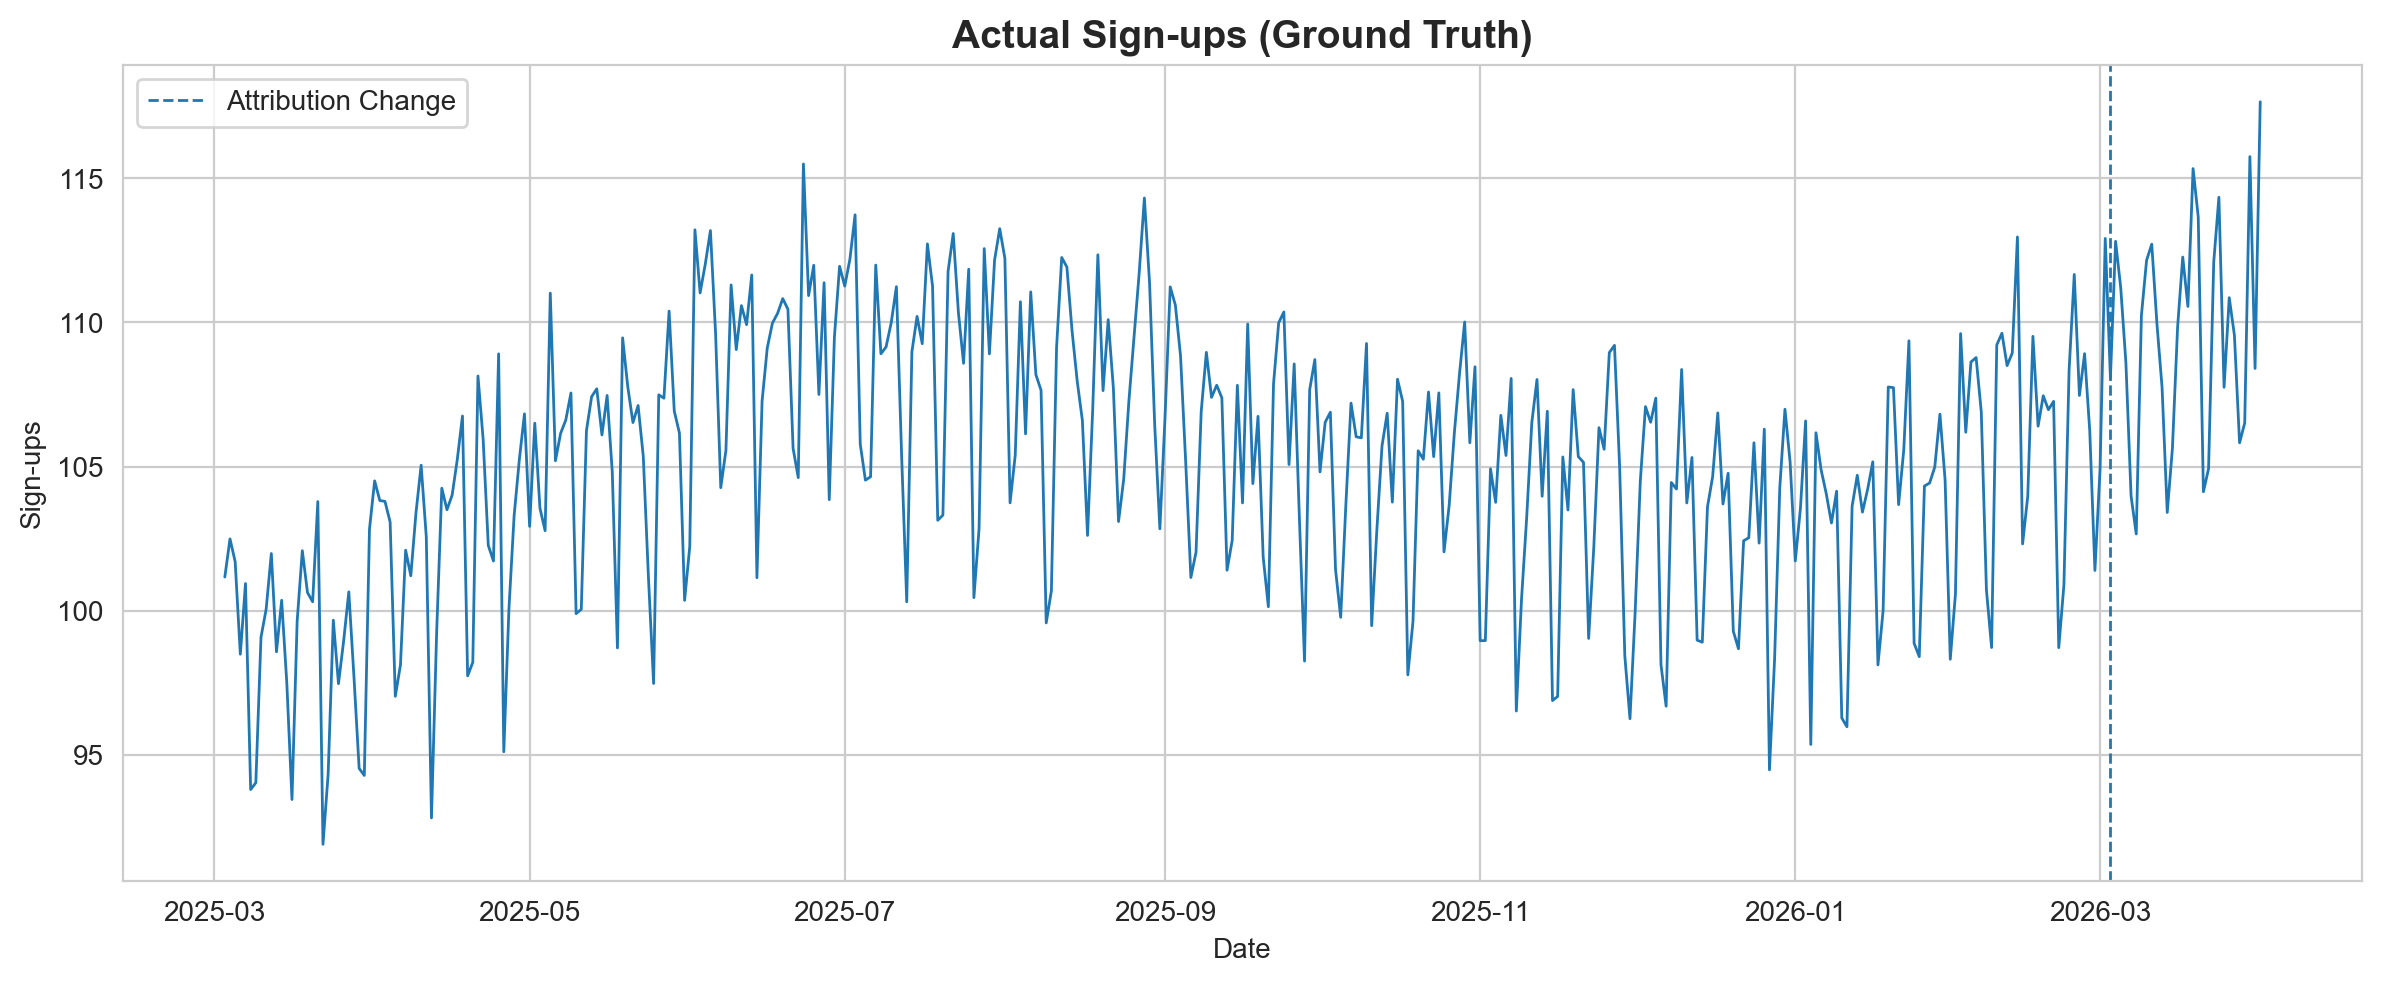

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["date"], df["signups"], linewidth=1)
ax.axvline(x=dates[intervention_day], linestyle="--", linewidth=1, label="Attribution Change")
ax.set_title("Actual Sign-ups (Ground Truth)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Sign-ups")
ax.legend()
plt.tight_layout()
plt.show()

No drop. The business is performing exactly as it was before.

The trend continues upward. The seasonality pattern is unchanged. The attribution change affected **what was reported**, not **what actually happened**.

But visual inspection alone is not enough. We need to test this formally.

## Interrupted Time Series Analysis

We run an ITS model on **actual sign-ups** (the ground truth) to test whether there was a statistically meaningful change at the intervention point.

The model learns the pre-intervention trend and projects a counterfactual into the post-intervention period. If the observed data falls within the counterfactual's uncertainty bands, we have no evidence of a real change.

In [5]:
yearly_terms = " + ".join(
    f"sin_yearly_{k} + cos_yearly_{k}" for k in range(1, 4)
)
weekly_terms = " + ".join(
    f"sin_weekly_{k} + cos_weekly_{k}" for k in range(1, 4)
)
formula = f"signups ~ 1 + t + {yearly_terms} + {weekly_terms}"
print(f"Formula: {formula}")

result = cp.InterruptedTimeSeries(
    df,
    treatment_time=intervention_day,
    formula=formula,
    model=cp.pymc_models.LinearRegression(
        sample_kwargs={"random_seed": 46, "progressbar": False}
    ),
)

Initializing NUTS using jitter+adapt_diag...


Formula: signups ~ 1 + t + sin_yearly_1 + cos_yearly_1 + sin_yearly_2 + cos_yearly_2 + sin_yearly_3 + cos_yearly_3 + sin_weekly_1 + cos_weekly_1 + sin_weekly_2 + cos_weekly_2 + sin_weekly_3 + cos_weekly_3


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


/Users/jakepiekarski/mmm_training/.pixi/envs/default/lib/python3.11/site-packages/pytensor/tensor/elemwise.py:710: RuntimeWarning: overflow encountered in exp
  variables = ufunc(*ufunc_args, **ufunc_kwargs)


...

Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


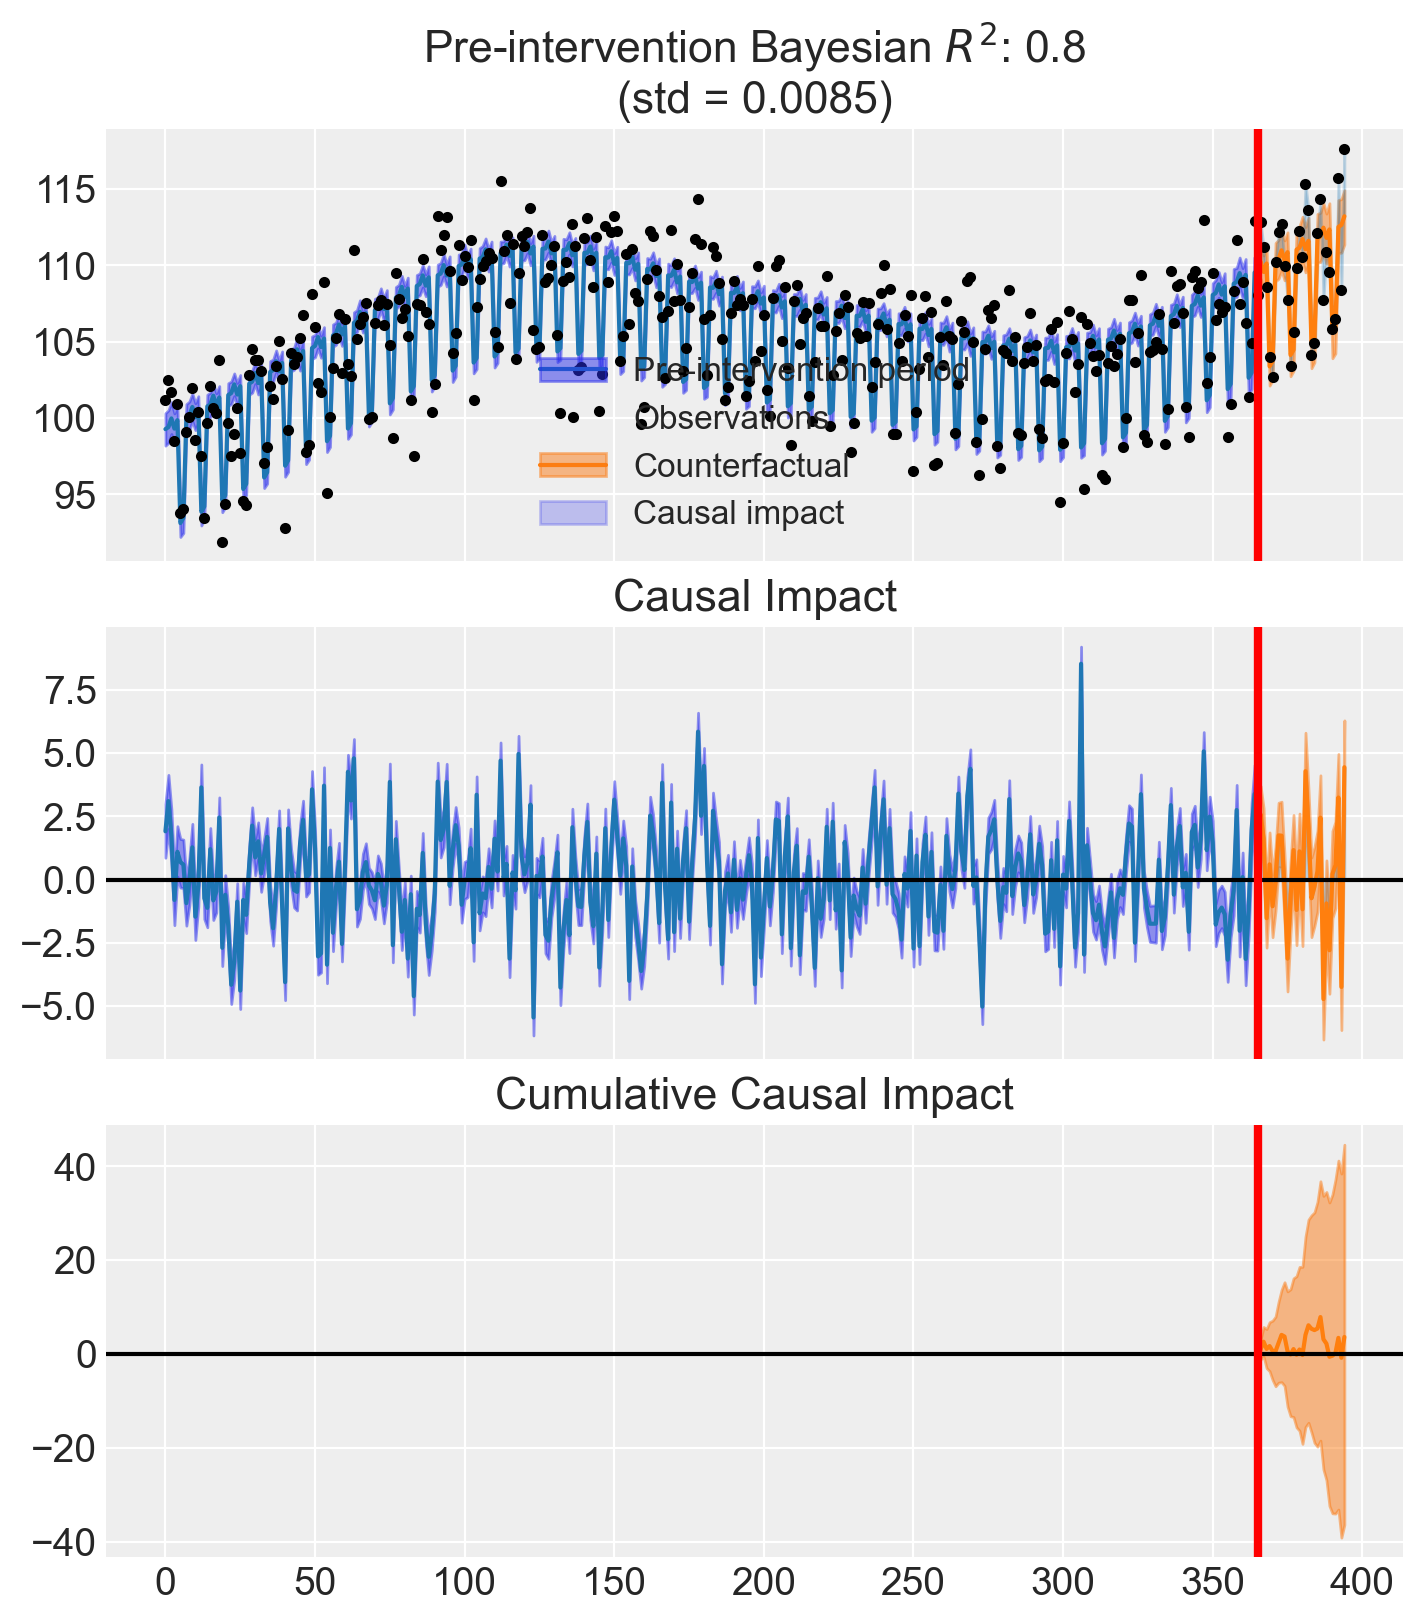

In [6]:
fig, ax = result.plot()

In [7]:
result.summary()

from sklearn.linear_model import LinearRegression as SklearnLR
from sklearn.metrics import r2_score

pre = df[df.index < intervention_day]
feature_cols = [c for c in df.columns if c.startswith(("sin_", "cos_")) or c == "t"]
r2 = SklearnLR().fit(pre[feature_cols], pre["signups"]).score(pre[feature_cols], pre["signups"])
print(f"\nPre-intervention R² = {r2:.3f}")

==================================Pre-Post Fit==================================
Formula: signups ~ 1 + t + sin_yearly_1 + cos_yearly_1 + sin_yearly_2 + cos_yearly_2 + sin_yearly_3 + cos_yearly_3 + sin_weekly_1 + cos_weekly_1 + sin_weekly_2 + cos_weekly_2 + sin_weekly_3 + cos_weekly_3
Model coefficients:
    Intercept     1e+02, 94% HDI [99, 101]
    t             0.028, 94% HDI [0.024, 0.033]
    sin_yearly_1  4.8, 94% HDI [4.2, 5.4]
    cos_yearly_1  -2.4, 94% HDI [-2.7, -2.2]
    sin_yearly_2  -0.031, 94% HDI [-0.41, 0.37]
    cos_yearly_2  -0.33, 94% HDI [-0.61, -0.054]
    sin_yearly_3  -0.052, 94% HDI [-0.39, 0.29]
    cos_yearly_3  0.42, 94% HDI [0.14, 0.71]
    sin_weekly_1  3.4, 94% HDI [3.1, 3.7]
    cos_weekly_1  -0.72, 94% HDI [-0.99, -0.43]
    sin_weekly_2  1, 94% HDI [0.74, 1.3]
    cos_weekly_2  2, 94% HDI [1.7, 2.3]
    sin_weekly_3  -0.92, 94% HDI [-1.2, -0.64]
    cos_weekly_3  0.56, 94% HDI [0.28, 0.83]
    y_hat_sigma   2, 94% HDI [1.9, 2.2]

Pre-intervention R² = 

In [8]:
stats = result.effect_summary()
print(stats.text)

During the Post-period (365 to 394), the response variable had an average value of approx. 109.62. By contrast, in the absence of an intervention, we would have expected an average response of 109.50. The 95% interval of this counterfactual prediction is [108.05, 110.87]. Subtracting this prediction from the observed response yields an estimate of the causal effect the intervention had on the response variable. This effect is 0.12 with a 95% interval of [-1.25, 1.57].

Summing up the individual data points during the Post-period, the response variable had an overall value of 3288.64. By contrast, had the intervention not taken place, we would have expected a sum of 3285.02. The 95% interval of this prediction is [3241.53, 3326.12].

The 95% HDI of the effect [-1.25, 1.57] includes zero. The posterior probability of an increase is 0.560. Relative to the counterfactual, the effect represents a 0.11% change (95% HDI [-1.13%, 1.45%]).

This analysis assumes that the relationship between th

## Interpreting the Results

The CausalPy effect summary above gives us a direct, quantitative answer.

The model compares observed sign-ups after the attribution change to what it would have expected based on the pre-intervention trend. The credible interval for the causal effect includes zero, meaning **there is no statistically meaningful evidence that sign-ups changed**.

To put it plainly:

| Source | Says | Reality |
|--------|------|---------|
| Meta Ads Manager | Performance dropped ~20% | Measurement changed |
| Actual sign-ups + ITS | No significant change | Business unaffected |

The platform said one thing. The experiment said another. They cannot both be right, and only one of them is measuring what actually matters.

## Business Implications

If a team relied solely on platform metrics to make decisions after this attribution change, here is what would likely happen:

- **Cutting budget** on campaigns that are actually performing well
- **Pausing strong campaigns** because reported conversions look low
- **Changing creatives** that were working, introducing unnecessary risk
- **Reallocating spend** to other channels based on a false comparison

Every one of these decisions would be wrong. Not because the team is incompetent, but because the data they relied on was never designed to answer the question they were asking.

Platform attribution answers: *"What did the platform observe?"*

Business decisions require: *"What actually caused this outcome?"*

## The Core Takeaway

> **Attribution tells you what a platform sees. Experimentation tells you what actually caused outcomes.**

These are not interchangeable.

- **Attribution** is unstable, platform-controlled, and subject to redefinition at any time. It is a reporting convention, not a measurement of truth.
- **Experimentation** is causal, decision-ready, and grounded in statistical evidence. It answers the question that actually matters: did this action cause a change in outcomes?

The Meta attribution update is not the problem. It is a symptom of a deeper issue: organizations building decision-making processes on top of metrics they do not control.

## CausalPy and Getting Started with Experimentation

[CausalPy](https://github.com/pymc-labs/CausalPy) makes causal inference accessible without requiring heavy infrastructure. It supports a range of quasi-experimental designs (interrupted time series, difference-in-differences, synthetic control, regression discontinuity, and more), all with Bayesian uncertainty quantification built in.

For teams that have not yet invested in experimentation, it is a practical entry point. You do not need a full experimentation platform to start answering causal questions. You need data, a plausible design, and the right tools.

For a deeper dive into the Bayesian ITS methodology used in this analysis, see the full [Bayesian Interrupted Time Series tutorial](https://causalpy.readthedocs.io/en/stable/notebooks/its_pymc.html) in the CausalPy documentation.

## Conclusion

The issue here is not Meta's update. The change itself is defensible. Aligning click-through attribution with what third-party tools report reduces confusion.

The issue is **relying on metrics you do not control** to make decisions that directly affect your business.

Attribution definitions will change again. They always do. The question is whether your measurement approach is resilient enough to tell the difference between a real performance shift and a reporting artifact.

> **"If you're not running experiments, you're guessing."**

Experimentation is not optional. It is the only way to know what is actually working.

---

If you're thinking about how to bring experimentation in-house, or need support running it, feel free to reach out. Always happy to talk through approaches.

**jakepiekarski@jtp-analytics.com**